# Mini-Series: Memory Without Words
>> **How Neural Networks Represent and Remember Knowledge**

# PART A. External Latent Memory

# SECTION 1. External Latent Memory

We build a memory matrix: N slots, each holding a latent vector. Think of it as a small RAM made of floating-point vectors.

<details>
<summary>Details: <strong>Why latent vectors, not tokens</strong></summary>

A Python dictionary stores strings. A database stores rows. The external latent memory stores *vectors* — the same floating-point tensors that flow through every layer of the network. This choice has one critical consequence: the memory is differentiable.

During training, gradients flow backward through the read and write operations and into the controller that decided *which* slot to address and *what* to write. This means the model can learn, from examples, how to use memory effectively — which slots to use for which kinds of information, when to overwrite, when to preserve. You do not hand-engineer a memory strategy; you train it.

Storing tokens instead of vectors would break this: the argmax operation that selects a token is not differentiable. This is precisely why latent-space memory and text-based RAG feel fundamentally different. RAG retrieves for you; NTM learns to retrieve.
</details>

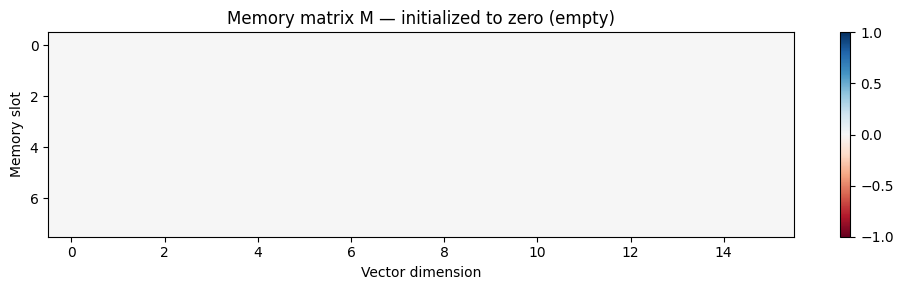

In [53]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

N_SLOTS: int = 8       # number of memory slots
VEC_DIM: int = 16      # dimensionality of each slot

# initialize memory to near-zero (empty memory)
memory: torch.Tensor = torch.zeros(N_SLOTS, VEC_DIM)

# visualize the empty memory matrix
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(memory.numpy(), cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
ax.set_xlabel("Vector dimension")
ax.set_ylabel("Memory slot")
ax.set_title("Memory matrix M — initialized to zero (empty)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Section 2 — Attention as Associative Memory

**Associative memory** is a memory system where: you retrieve stored information not by an address, but by similarity to a cue.

This is the opposite of RAM, where you say “give me slot #42.”

In associative memory, you say: “Here is a pattern. Give me one or few of the stored patterns that most resembles it.”

This is how humans recall:
- You hear the first notes of a song → the whole melody comes back
- You see a fragment of a face → you remember the person
- You smell something → you recall a childhood scene
The cue associates to the stored memory.

**Let's build a basic pattern association primitive

>> A single attention step is a basic pattern‑association primitive: a query representation acts as a retrieval cue, selecting the stored representation whose key is most similar. This is precisely the operation performed by modern Hopfield networks and other associative memory systems.

**Computing Attention**

1. Memory is a set of facts represented as **values**: meanings / concepts / features / facts / embeddings / representations
2. Each of the values is characterized by a **key**: a characteristic property of the value that represents its proposition
3. To use the memory we should use **queries** which we will associate with **keys** -> **attenton** of the query to each of facts

| Component | Role |
|-----------|------|
| Value     | Product to buy and use |
| Key       | Advertisement of the product |
| Query     | Consumer's need in a product |
| Attention | A probability that this product suits this user's need |

Memory usage route:

```
Shopping:
  -> Query (shopping needs)
  -> Map to product keys (need-to-advertisement) 
  -> selected keys (shopping list) 
  -> products (shopping cart)
```


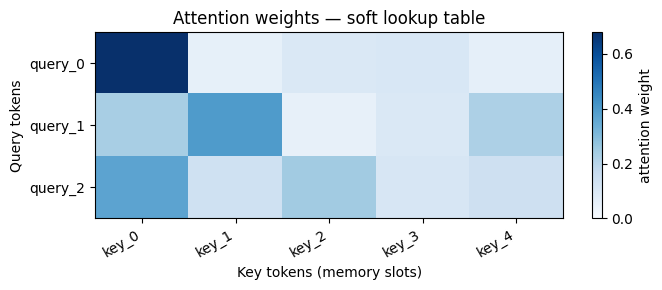

Query 'query_1' retrieves mostly from key 'key_1' (weight=0.396) — this is a soft lookup


In [5]:
# Computing Attention Of Multiple Queries to Multiple Memory Slots

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42) # Make the world deterministic

# --- dimensions and synthetic query / key / value tensors ---
n_queries: int = 3  # Number of shopping needs
n_keys: int = 5     # Number of value providers (1 key per value)
d_k: int = 8        # Dimensionality of representations

Q: torch.Tensor = torch.randn(n_queries, d_k) # What to ask every from every provider (shopping)
K: torch.Tensor = torch.randn(n_keys, d_k)    # What this provider can offer to every other token (advertisement)
V: torch.Tensor = torch.randn(n_keys, d_k)    # What this provider will produce when selected (product)
# Values are: features, meanings, concepts, attractors, facts, embeddings, memory slots -> representations

# Define shopping requests and provider offerings
query_labels: list[str] = [f"query_{i}" for i in range(n_queries)]
key_labels: list[str] = [f"key_{i}" for i in range(n_keys)]

# --- scaled dot-product attention scores ---
# Each query vector (Q) is compared to every key vector (K) using a dot product, 
# producing a matrix of similarity scores. 
# The division by \sqrt{d_k} prevents the scores from blowing up as dimensionality grows.
# This is scaled Dot-Product Attention trick from Vaswani et al. (2017).
scores: torch.Tensor = Q @ K.T / (d_k ** 0.5)       # shape: (n_queries, n_keys)

# Turns raw similarity scores into a probability distribution
# All weights are positive. They sum to 1. Higher similarity → higher weight.
# For each query, softmax decides how much attention to pay to each key.
weights: torch.Tensor = F.softmax(scores, dim=-1)   # shape: (n_queries, n_keys) Normalized probabilities

# --- visualize attention weights as a heatmap ---
fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow( # Defined how each attention weight becomes a color.
    weights.detach().numpy(), cmap="Blues", aspect="auto", 
    vmin=0, vmax=weights.max().item()
)
ax.set_xticks(range(n_keys))
ax.set_xticklabels(key_labels, rotation=30, ha="right")
ax.set_yticks(range(n_queries))
ax.set_yticklabels(query_labels)
ax.set_xlabel("Key tokens (memory slots)")
ax.set_ylabel("Query tokens")
ax.set_title("Attention weights — soft lookup table")
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

# --- identify the strongest retrieved key for query_1 ---
top_key_idx: int = int(weights[1].argmax().item())
print(f"Query 'query_1' retrieves mostly from key '{key_labels[top_key_idx]}' "
      f"(weight={weights[1, top_key_idx]:.3f}) — this is a soft lookup")

<details>
<summary>Modern hopfield networks — attention is energy minimization</summary>

In 2020, Ramsauer et al. showed that the scaled dot-product attention update rule is mathematically equivalent to one step of energy minimization in a *modern Hopfield network* — a generalization of the classical 1982 Hopfield associative memory. The stored patterns are the rows of the value matrix V, and the retrieval cue is the query Q. The softmax ensures the system converges toward the stored pattern most similar to the cue, rather than getting stuck in spurious attractors.

The key insight is that attention was already doing associative memory retrieval — the transformer community just did not name it that way. When you run a softmax over dot products between a query and a set of keys, you are performing one iteration of a content-addressable memory lookup. This reframing is not merely academic: it explains *why* attention generalizes so well, and it directly motivates the NTM architecture we build in Section 2 — which simply makes the memory matrix a trainable external store rather than a fixed set of context tokens.

</details>


## 1b — What Does a Value Vector Actually Represent?

Before we write vectors into NTM memory, we should ask a harder question: *what is a vector, and what does it encode?*

A latent vector is a coordinate in a high-dimensional space. But which space depends on several interlocking choices:

**What produced it.**
A token embedding lives close to lexical meaning — the word “bank” has one embedding regardless of whether it means a riverbank or a financial institution. One layer deeper, the vector has been touched by attention: neighboring tokens have contributed to its representation. By layer 12 in a large model, “bank” after “the river” and “bank” after “wire transfer” live in completely different regions of the space.

**When in the sequence it was produced.**
The same word at position 3 (no history yet) produces a different vector than at position 300 (full context already processed). Position is not just an address — it changes the representation.

**How it was pooled.**
A single token vector captures one moment. A mean-pooled span captures a summary. The last-token hidden state of an autoregressive model often acts as a compressed summary of everything before it.

When NTM writes a vector into a memory slot, it writes *one specific point in one specific space* — shaped by all of the above. The slot does not contain “the word Paris.” It contains whatever internal representation the controller chose to write at that moment in that context.

The visualization below makes this concrete: the same token extracted at three different transformer depths. The vectors look different — because they *are* different things.


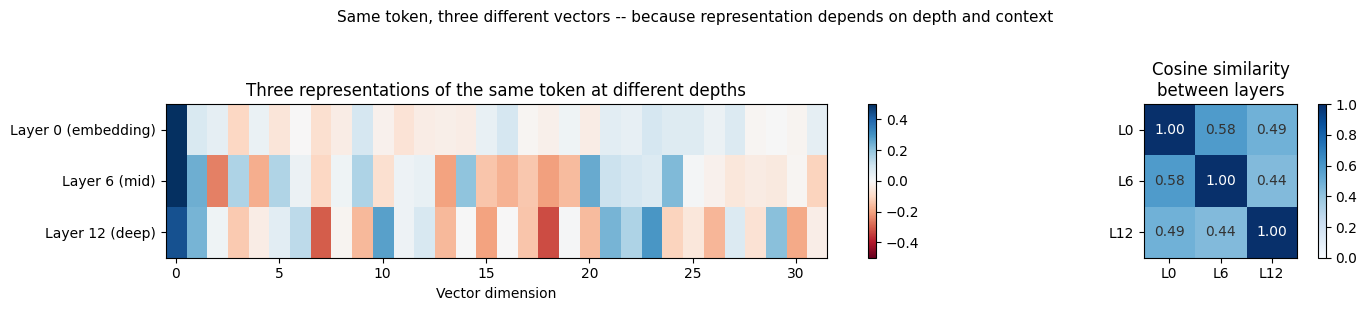

Cosine similarity between layer representations:
  L0 <-> L6: 0.582
  L0 <-> L12: 0.487
  L6 <-> L12: 0.443

The same token is a different vector at each layer.
NTM writes one of these -- but which one? That choice determines what 'memory of X' means.


In [54]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# synthetic vectors constructed to reflect what layer-probing studies find:
# early layers stay close to the token embedding; later layers rotate substantially.

D: int = 32

# layer 0: raw token embedding -- strong single-dimension lexical signal
layer0_vec: torch.Tensor = torch.zeros(D)
layer0_vec[0] = 1.0
layer0_vec = layer0_vec + torch.randn(D) * 0.05

# layer 6: neighbors have started reshaping the representation via attention
rotation6: torch.Tensor = torch.randn(D, D) * 0.15
layer6_vec: torch.Tensor = F.normalize(layer0_vec + rotation6 @ layer0_vec, dim=0)

# layer 12: fully contextualized; original lexical signal substantially mixed in
rotation12: torch.Tensor = torch.randn(D, D) * 0.4
layer12_vec: torch.Tensor = F.normalize(layer0_vec + rotation12 @ layer6_vec, dim=0)

# stack into matrix: 3 rows (layers) x D columns (dimensions)
layer_matrix: np.ndarray = torch.stack(
    [layer0_vec, layer6_vec, layer12_vec]
).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 3),
                         gridspec_kw={"width_ratios": [2, 1]})

# left: heatmap of the three representations
im = axes[0].imshow(layer_matrix, cmap="RdBu", vmin=-0.5, vmax=0.5, aspect="auto")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Layer 0 (embedding)", "Layer 6 (mid)", "Layer 12 (deep)"])
axes[0].set_xlabel("Vector dimension")
axes[0].set_title("Three representations of the same token at different depths")
plt.colorbar(im, ax=axes[0])

# right: pairwise cosine similarities between the three layer vectors
vecs: list[torch.Tensor] = [layer0_vec, layer6_vec, layer12_vec]
layer_labels: list[str] = ["L0", "L6", "L12"]
sim_matrix: np.ndarray = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        sim_matrix[i, j] = float(
            F.cosine_similarity(vecs[i].unsqueeze(0), vecs[j].unsqueeze(0)).item()
        )

im2 = axes[1].imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(layer_labels)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(layer_labels)
axes[1].set_title("Cosine similarity\nbetween layers")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{sim_matrix[i,j]:.2f}",
                     ha="center", va="center", fontsize=10,
                     color="white" if sim_matrix[i, j] > 0.6 else "#333")
plt.colorbar(im2, ax=axes[1])

plt.suptitle(
    "Same token, three different vectors"
    " -- because representation depends on depth and context",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print("Cosine similarity between layer representations:")
for i, li in enumerate(layer_labels):
    for j, lj in enumerate(layer_labels):
        if j > i:
            print(f"  {li} <-> {lj}: {sim_matrix[i, j]:.3f}")
print()
print("The same token is a different vector at each layer.")
print("NTM writes one of these -- but which one? That choice determines what 'memory of X' means.")


<details>
<summary>why softmax and not argmax</summary>

The tempting implementation is: find the slot with the highest cosine similarity and address only that one. This is argmax — and it is not differentiable. The gradient of argmax with respect to its input is zero almost everywhere and undefined at the maximum. No gradient means the controller cannot learn *which* slot to use for *what* purpose.

Softmax is the differentiable relaxation. It produces a probability distribution that is *almost* a one-hot vector when one similarity is much larger than the others, but the gradient flows smoothly back to every similarity score. During training, the model learns to produce queries that are very similar to the keys of the correct slot — making the softmax increasingly sharp and the addressing increasingly precise.

This is the core trick that makes NTM trainable end-to-end: replace every discrete selection operation with a soft, weighted combination. Read becomes a weighted sum. Write becomes a weighted update. The entire system is one smooth function, differentiable from output to input.

</details>

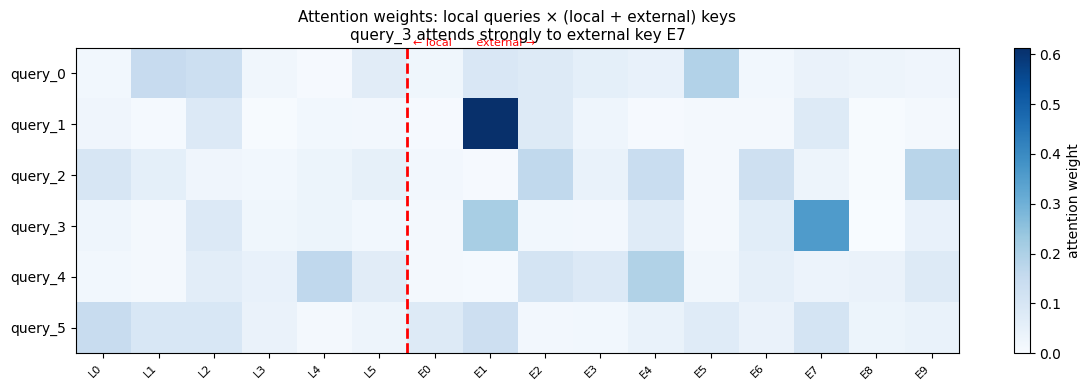

query_3 top attention → column 13 = 'E7' (weight=0.357)


In [14]:
torch.manual_seed(5)

D_MODEL: int = 16
N_LOCAL: int = 6      # tokens in the local window
N_EXT: int = 10       # past (K, V) pairs in external memory bank

# --- local context: Q, K, V for current window ---
local_Q: torch.Tensor = torch.randn(N_LOCAL, D_MODEL)
local_K: torch.Tensor = torch.randn(N_LOCAL, D_MODEL)
local_V: torch.Tensor = torch.randn(N_LOCAL, D_MODEL)

# --- external memory bank: 10 past key-value pairs ---
ext_K: torch.Tensor = torch.randn(N_EXT, D_MODEL)
ext_V: torch.Tensor = torch.randn(N_EXT, D_MODEL)

# --- plant a strong match: local query 3 should retrieve external key 7 ---
ext_K[7] = F.normalize(local_Q[3] + 0.05 * torch.randn(D_MODEL), dim=0) * 3.0

# --- concatenate local and external keys/values ---
K_full: torch.Tensor = torch.cat([local_K, ext_K], dim=0)   # (N_LOCAL + N_EXT, D_MODEL)
V_full: torch.Tensor = torch.cat([local_V, ext_V], dim=0)

# --- compute attention scores for all queries against the full key set ---
attn_scores: torch.Tensor = local_Q @ K_full.T / (D_MODEL ** 0.5)
attn_weights: torch.Tensor = F.softmax(attn_scores, dim=-1)  # (N_LOCAL, N_LOCAL + N_EXT)

# --- visualize: rows = local queries, columns = local + external keys ---
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    attn_weights.detach().numpy(), cmap="Blues",
    aspect="auto", vmin=0, vmax=attn_weights.max().item()
)

# column labels
col_labels: list[str] = (
    [f"L{i}" for i in range(N_LOCAL)] +
    [f"E{i}" for i in range(N_EXT)]
)
ax.set_xticks(range(N_LOCAL + N_EXT))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(N_LOCAL))
ax.set_yticklabels([f"query_{i}" for i in range(N_LOCAL)])

# vertical dashed separator between local and external
ax.axvline(x=N_LOCAL - 0.5, color="red", linewidth=2, linestyle="--", label="local | external")
ax.text(N_LOCAL - 0.5 + 0.1, -0.7, "← local       external →",
        color="red", fontsize=8, va="top")

ax.set_title(
    "Attention weights: local queries × (local + external) keys\n"
    "query_3 attends strongly to external key E7",
    fontsize=11
)
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

# confirm query 3's strongest key
top_col: int = int(attn_weights[3].argmax().item())
print(f"query_3 top attention → column {top_col} = '{col_labels[top_col]}' "
      f"(weight={attn_weights[3, top_col]:.3f})")

<details>
<summary>why the same vocabulary matters</summary>

In NTM, memory access is a separate mechanism bolted onto the model — a controller with dedicated read and write heads that use a different addressing scheme than the main attention layers. It works, but there is a seam: the model has two representational worlds and must translate between them.

Memorizing Transformers (Wu et al., 2022) remove the seam. The external memory bank stores (K, V) pairs in exactly the same format as the local context. The retrieval operation is exactly the same scaled dot-product attention the model uses for everything else. There is no mode switch, no separate read head, no translation step.

This means that when you extend a standard transformer with a Memorizing Transformer memory bank, you are not adding a new capability — you are extending an existing one. The model's internal language (the geometry of its key and query spaces) does not change. Past context and current context are both keys and values; the model cannot tell — and does not need to know — which side of the separator line a particular key came from.

</details>

The boundary between local context and retrieved memory is architectural, not representational. The model does not know — or care — which side of the line a key came from.